In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('/content/Housing.csv')
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [ ]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [ ]:
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


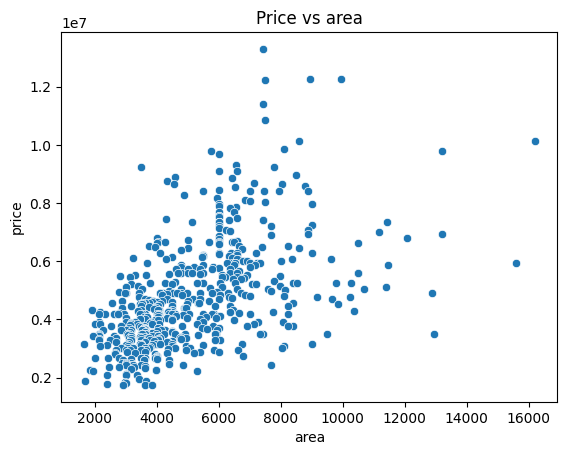

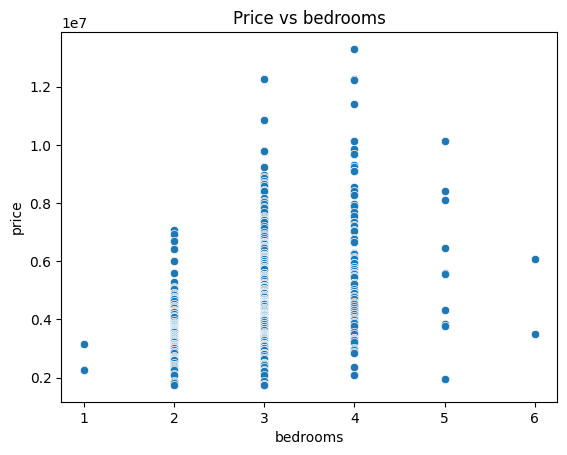

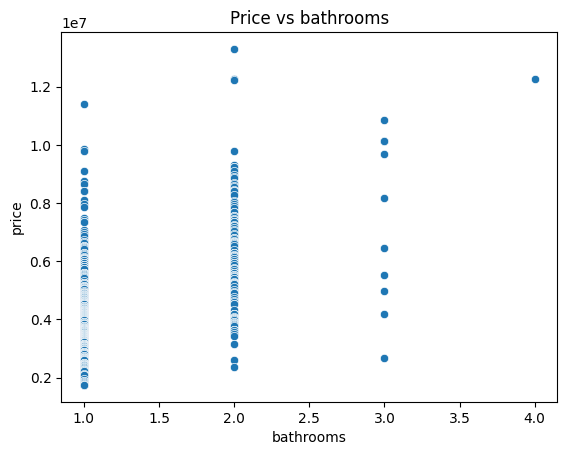

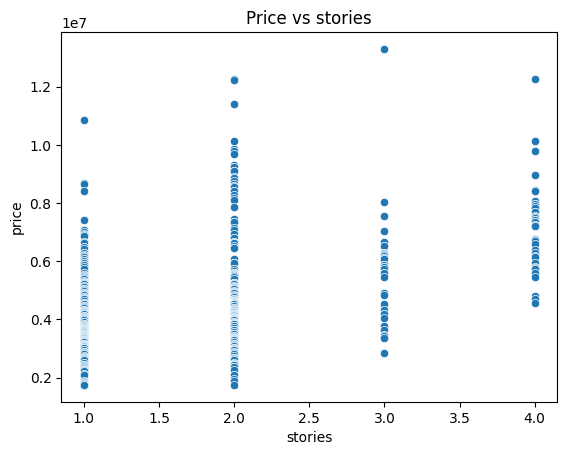

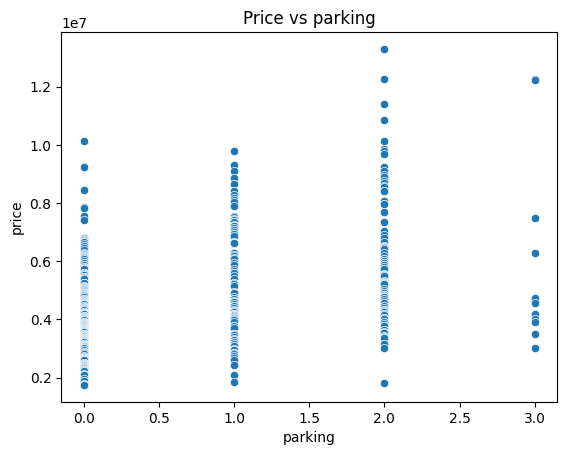

In [ ]:
num_features = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']

for feature in num_features:
    sns.scatterplot(data=df, x=feature, y='price')
    plt.title(f'Price vs {feature}')
    plt.show()

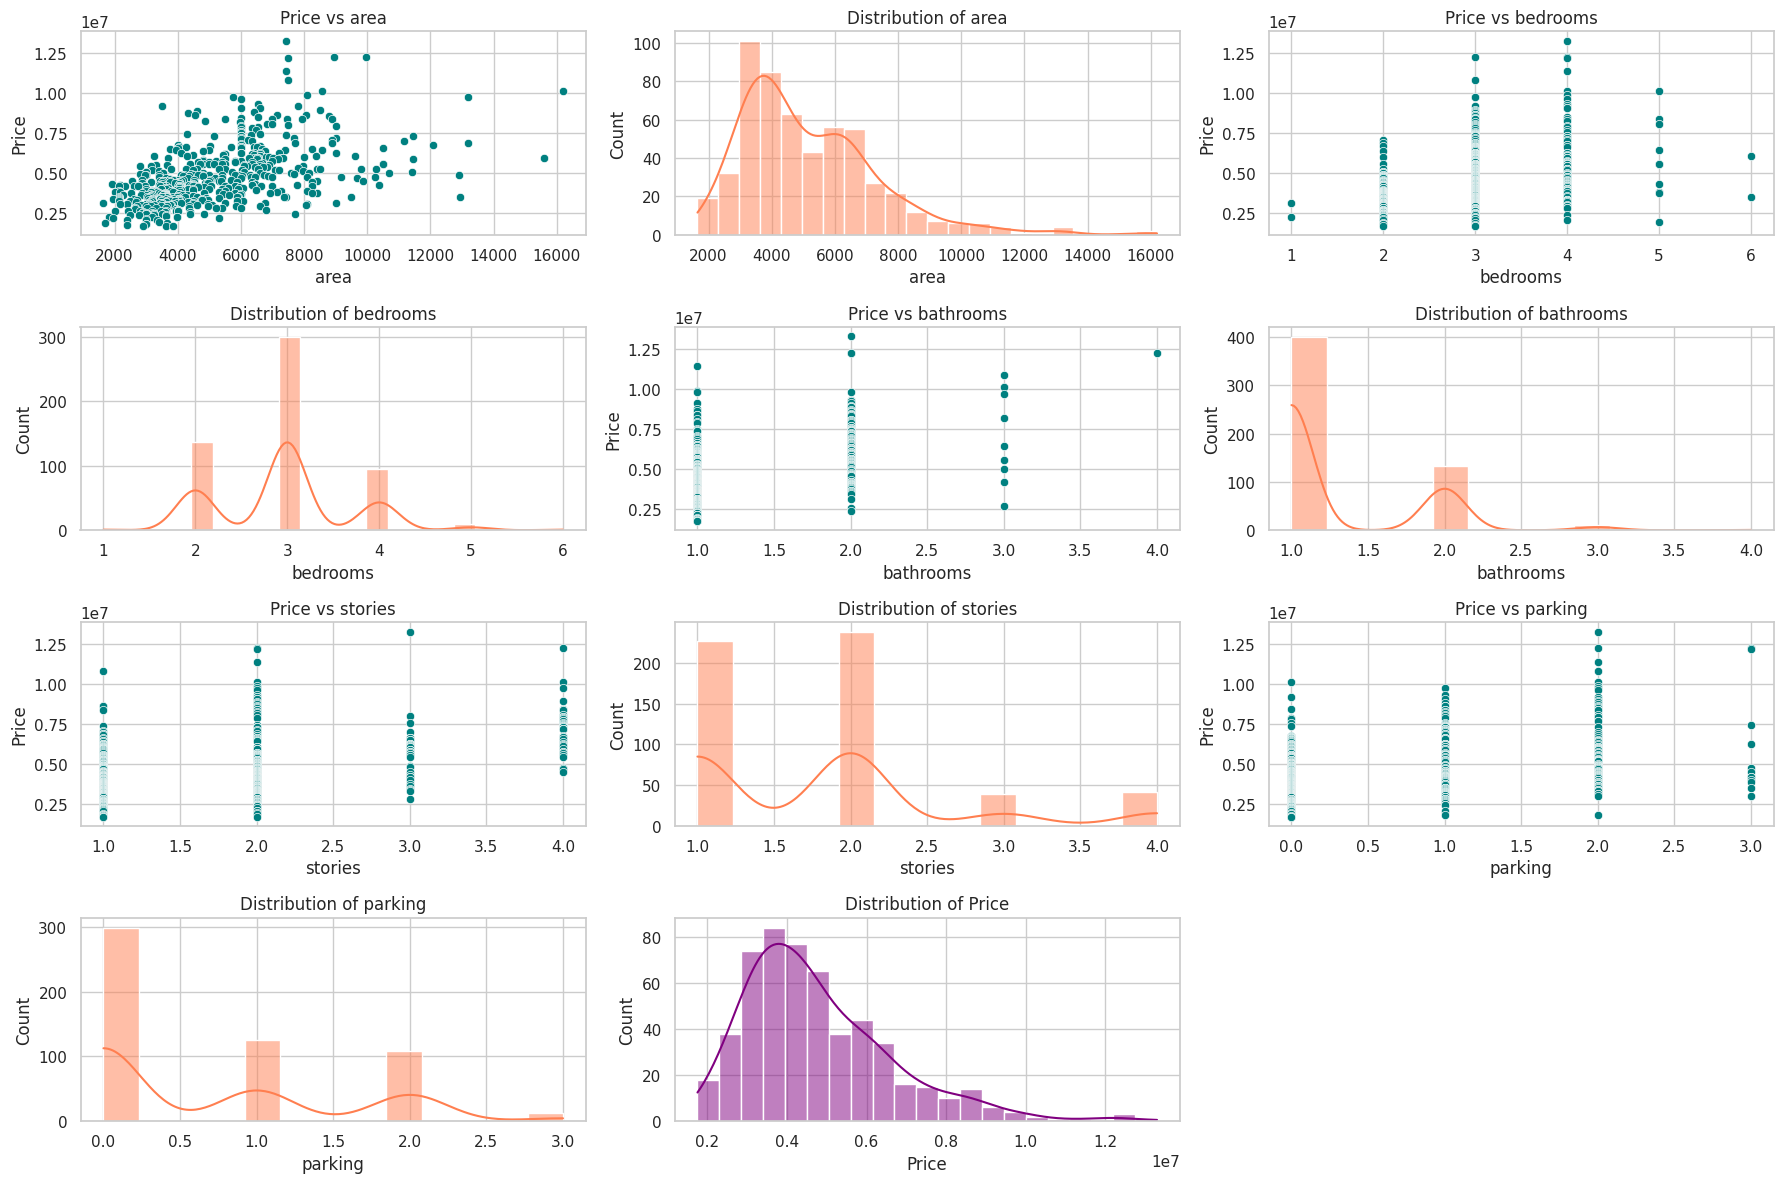

In [ ]:
sns.set(style="whitegrid")

# Important numerical features
features = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']

# Create subplots for scatter plots and histograms
plt.figure(figsize=(18, 12))

for i, feature in enumerate(features):
    # Scatter plot (Price vs Feature)
    plt.subplot(4, 3, i*2 + 1)
    sns.scatterplot(x=df[feature], y=df['price'], color='teal')
    plt.title(f'Price vs {feature}')
    plt.xlabel(feature)
    plt.ylabel('Price')

    # Histogram (Distribution of Feature)
    plt.subplot(4, 3, i*2 + 2)
    sns.histplot(df[feature], kde=True, color='coral')
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)

# Histogram for Price
plt.subplot(4, 3, 11)
sns.histplot(df['price'], kde=True, color='purple')
plt.title('Distribution of Price')
plt.xlabel('Price')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
encoder=LabelEncoder()
df['furnishingstatus']=encoder.fit_transform(df['furnishingstatus'])
df['mainroad']=encoder.fit_transform(df['mainroad'])
df['guestroom']=encoder.fit_transform(df['guestroom'])
df['basement']=encoder.fit_transform(df['basement'])
df['hotwaterheating']=encoder.fit_transform(df['hotwaterheating'])
df['airconditioning']=encoder.fit_transform(df['airconditioning'])

x=df.drop('price',axis=1)
y=df['price']

scalars=StandardScaler()
x_scaled=scalars.fit_transform(x)



In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    int64
 6   guestroom         545 non-null    int64
 7   basement          545 non-null    int64
 8   hotwaterheating   545 non-null    int64
 9   airconditioning   545 non-null    int64
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    int64
 12  furnishingstatus  545 non-null    int64
dtypes: int64(13)
memory usage: 55.5 KB


In [ ]:
import sklearn.model_selection as model_selection
x_train,x_test,y_train,y_test=model_selection.train_test_split(x_scaled,y,test_size=0.2)
import sklearn.linear_model as linear_model
from sklearn.linear_model import  Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.pipeline import make_pipeline


In [ ]:


model=linear_model.LinearRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)

model_ridge = Ridge(alpha=1.0)
model_ridge.fit(x_train, y_train)
y_pred_ridge = model_ridge.predict(x_test)

model_lasso = Lasso(alpha=1.0)
model_lasso.fit(x_train, y_train)
y_pred_lasso = model_lasso.predict(x_test)

model_poly = make_pipeline(PolynomialFeatures(degree=2), linear_model.LinearRegression())
model_poly.fit(x_train, y_train)
y_pred_poly = model_poly.predict(x_test)


Model                           RMSE         R2        MAE
------------------------------------------------------------
Linear Regression         1322425.19     0.6155  914691.62
Polynomial Regression     1590446.03     0.4439 1037104.61
Ridge Regression          1322770.22     0.6153  914729.98
Lasso Regression          1322425.19     0.6155  914691.62


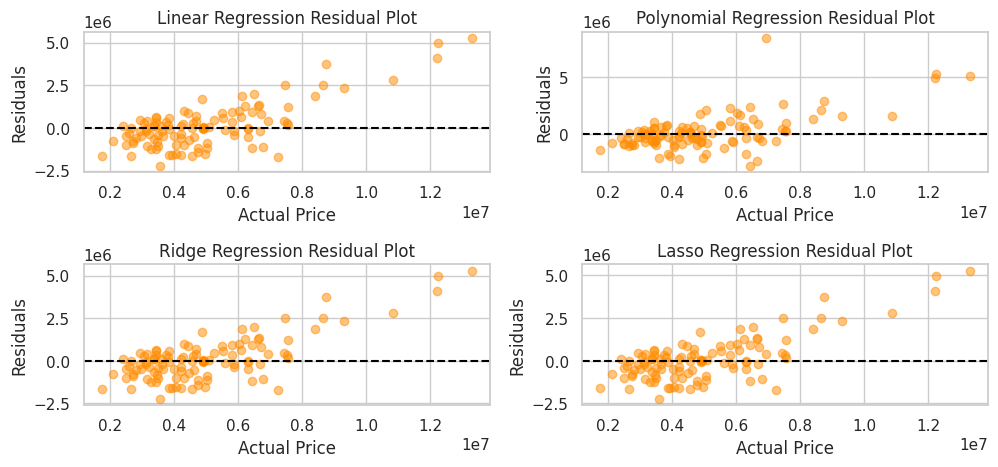

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Dictionary to store model predictions
models = {
    "Linear Regression": y_pred,
    "Polynomial Regression": y_pred_poly,
    "Ridge Regression": y_pred_ridge,
    "Lasso Regression": y_pred_lasso
}

# Evaluate and display performance
print("{:<25} {:>10} {:>10} {:>10}".format("Model", "RMSE", "R2", "MAE"))
print("-" * 60)

for name, y_pred in models.items():
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    print(f"{name:<25} {rmse:10.2f} {r2:10.4f} {mae:10.2f}")

# Residual Plot (Actual - Predicted)
plt.figure(figsize=(10, 5))
for i, (name, y_pred) in enumerate(models.items(), 1):
    plt.subplot(2, 2, i)
    residuals = y_test - y_pred
    plt.scatter(y_test, residuals, alpha=0.5, color='darkorange')
    plt.axhline(0, color='black', linestyle='--')
    plt.title(f"{name} Residual Plot")
    plt.xlabel("Actual Price")
    plt.ylabel("Residuals")

plt.tight_layout()
plt.show()
